<a href="https://colab.research.google.com/github/Adidtiasmara/PCVK26_16_Firman/blob/main/Week6_16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
NAMA = 'Muhammad Firman Aditiasmara'
NIM = '244107020094'
print(NAMA, NIM)

Muhammad Firman Aditiasmara 244107020094


In [20]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

In [ ]:
DIR = '/content/drive/MyDrive/PCVK/Gambar'

In [22]:
def convolution2d(image, kernel, stride=1, padding=0):
    # Tambahkan padding jika diperlukan
    if padding > 0:
        image = np.pad(
            image,
            padding,
            mode='constant',
            constant_values=0
        )

    image_height = image.shape[0]
    image_width = image.shape[1]
    filter_height = kernel.shape[0]
    filter_width = kernel.shape[1]

    output_height = (image_height - filter_height) // stride + 1
    output_width = (image_width - filter_width) // stride + 1

    z = np.zeros((output_height, output_width), dtype=float)

    # Algoritma konvolusi sesuai modul
    for x in range(output_width):
        for y in range(output_height):
            z[y, x] = 0
            for k1 in range(filter_height):
                for k2 in range(filter_width):
                    img_y = y * stride + k1
                    img_x = x * stride + k2
                    z[y, x] = z[y, x] + kernel[k1, k2] * image[img_y, img_x]

    return z

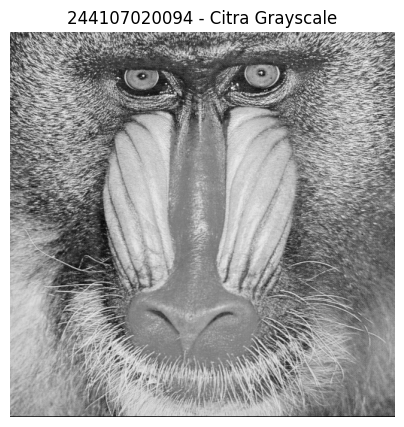

In [23]:
img = cv.imread(DIR + '/mandrill.tiff')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
plt.figure(figsize=(5, 5))
plt.imshow(img_gray, cmap='gray')
plt.title(NIM + ' - Citra Grayscale')
plt.axis('off')
plt.show()

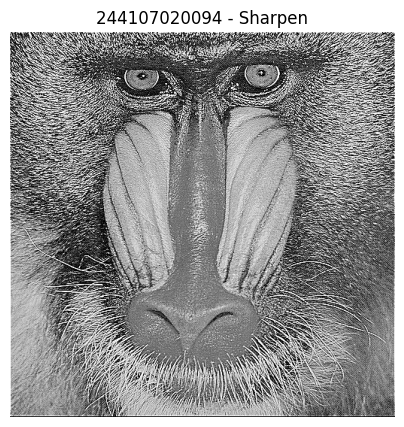

In [24]:
kernel_sharpen = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
], dtype=float)

hasil_sharpen = convolution2d(
    img_gray,
    kernel_sharpen,
    stride=1,
    padding=1
)

# Clip hasil ke rentang 0-255
hasil_sharpen = np.clip(hasil_sharpen, 0, 255).astype(np.uint8)

plt.figure(figsize=(5, 5))
plt.imshow(hasil_sharpen, cmap='gray')
plt.title(NIM + ' - Sharpen')
plt.axis('off')
plt.show()

In [25]:
kernel_average = np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
], dtype=float) / 9

# Low Pass Filter
kernel_low_pass = np.array([
    [1, 1, 1],
    [1, 4, 1],
    [1, 1, 1]
], dtype=float) / 12

# High Pass Filter
kernel_high_pass = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=float)

# Emboss
kernel_emboss = np.array([
    [-2, -1, 0],
    [-1, 1, 1],
    [0, 1, 2]
], dtype=float)

# Left Sobel Edge Detection
kernel_sobel = np.array([
    [1, 0, -1],
    [2, 0, -2],
    [1, 0, -1]
], dtype=float)

# Canny Edge Detection
kernel_canny = np.array([
    [-1, -1, -1],
    [-1, 8, -1],
    [-1, -1, -1]
], dtype=float)

kernel_size = 21
sigma = math.sqrt(kernel_size)

gaussian_kernel = cv.getGaussianKernel(kernel_size, sigma)
gauss_kernel = gaussian_kernel @ gaussian_kernel.transpose()

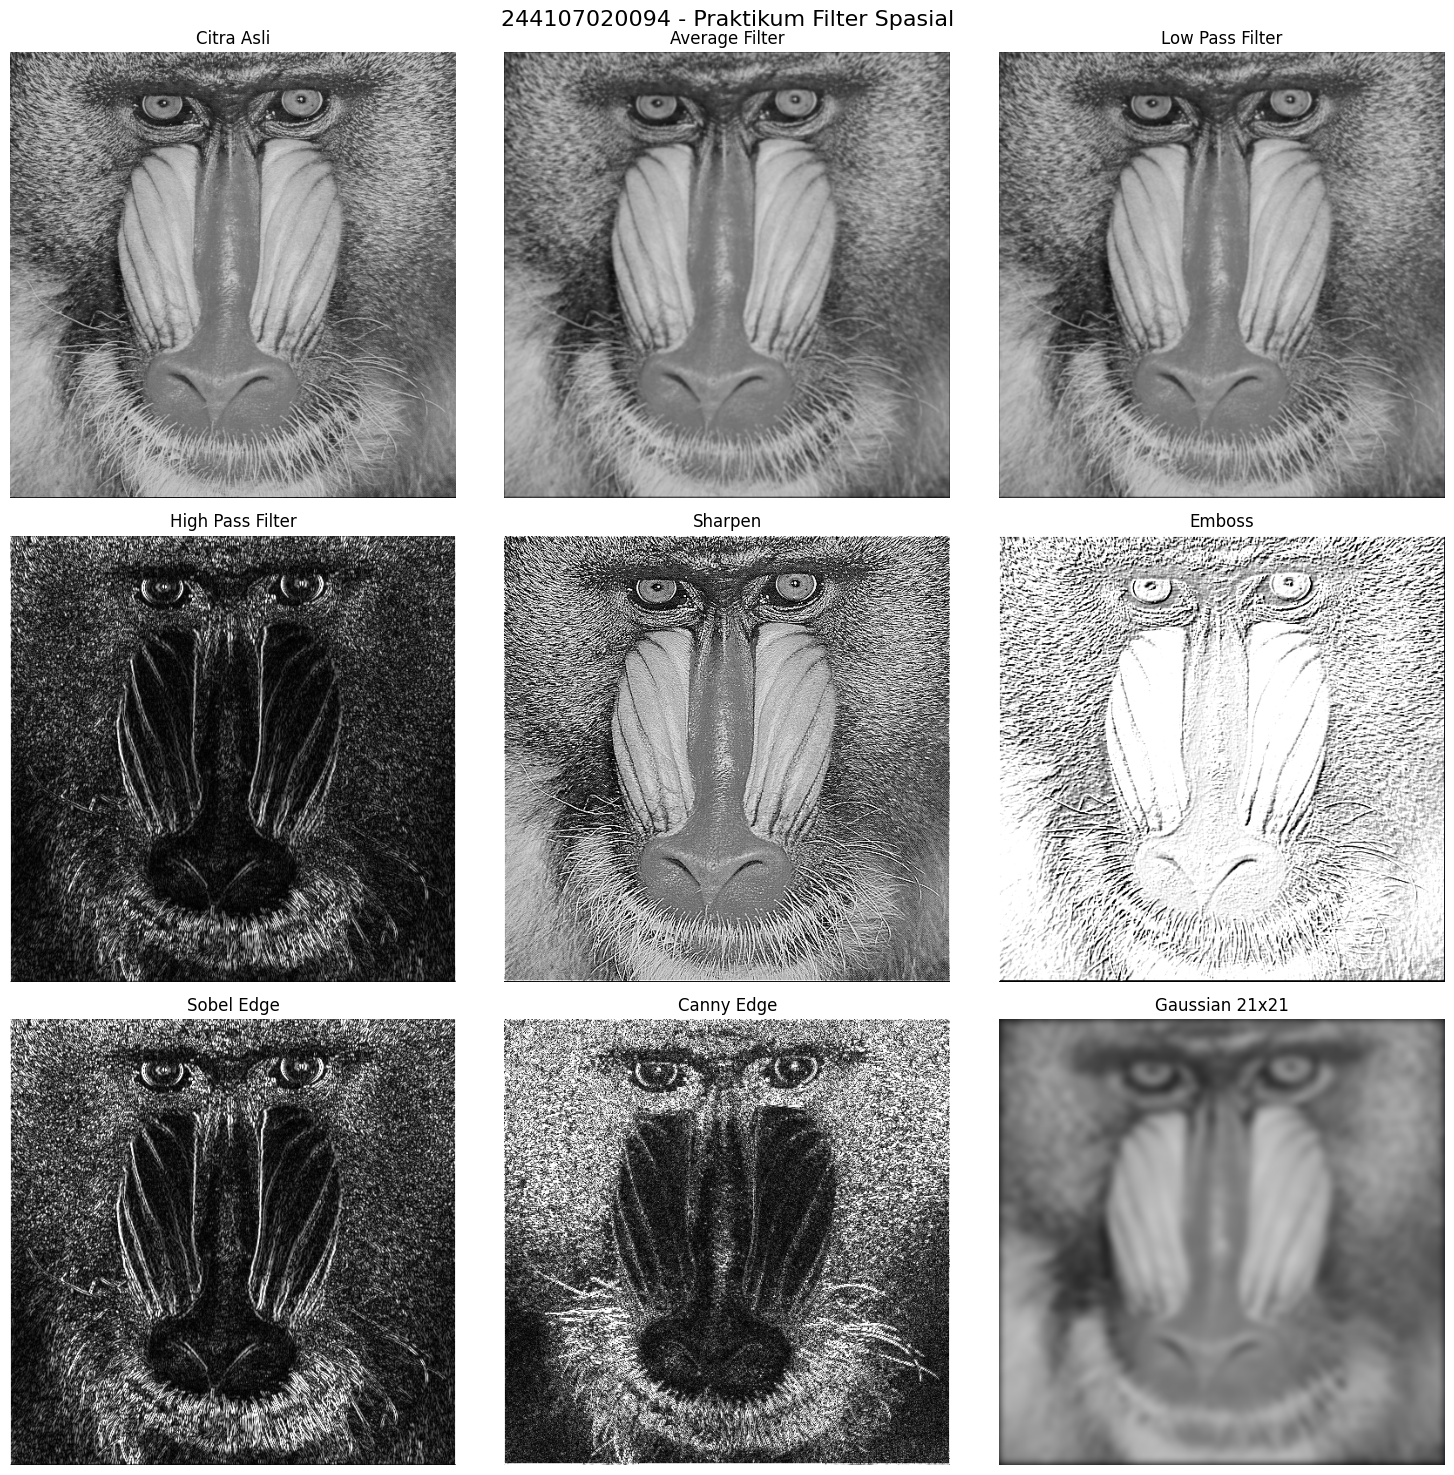

In [ ]:
hasil_average = convolution2d(img_gray, kernel_average, 1, 1)
hasil_average = np.clip(hasil_average, 0, 255).astype(np.uint8)

hasil_low_pass = convolution2d(img_gray, kernel_low_pass, 1, 1)
hasil_low_pass = np.clip(hasil_low_pass, 0, 255).astype(np.uint8)

hasil_high_pass = convolution2d(img_gray, kernel_high_pass, 1, 1)
hasil_high_pass = np.clip(np.abs(hasil_high_pass), 0, 255).astype(np.uint8)

hasil_emboss = convolution2d(img_gray, kernel_emboss, 1, 1)
hasil_emboss = np.clip(hasil_emboss + 128, 0, 255).astype(np.uint8)

hasil_sobel = convolution2d(img_gray, kernel_sobel, 1, 1)
hasil_sobel = np.clip(np.abs(hasil_sobel), 0, 255).astype(np.uint8)

hasil_canny = convolution2d(img_gray, kernel_canny, 1, 1)
hasil_canny = np.clip(np.abs(hasil_canny), 0, 255).astype(np.uint8)

hasil_gaussian = convolution2d(img_gray, gauss_kernel, 1, 10)
hasil_gaussian = np.clip(hasil_gaussian, 0, 255).astype(np.uint8)

judul = [
    'Citra Asli',
    'Average Filter',
    'Low Pass Filter',
    'High Pass Filter',
    'Sharpen',
    'Emboss',
    'Sobel Edge',
    'Canny Edge',
    'Gaussian 21x21'
]

citra = [
    img_gray,
    hasil_average,
    hasil_low_pass,
    hasil_high_pass,
    hasil_sharpen,
    hasil_emboss,
    hasil_sobel,
    hasil_canny,
    hasil_gaussian
]

fig, axs = plt.subplots(3, 3, figsize=(15, 15))
fig.suptitle(NIM + ' - Praktikum Filter Spasial', fontsize=16)

for ax, gambar, nama in zip(axs.ravel(), citra, judul):
    ax.imshow(gambar, cmap='gray', vmin=0, vmax=255)
    ax.set_title(nama)
    ax.axis('off')

plt.tight_layout()
plt.show()

##**E. FILTER LIBRARY DAN FILTER MODERN**

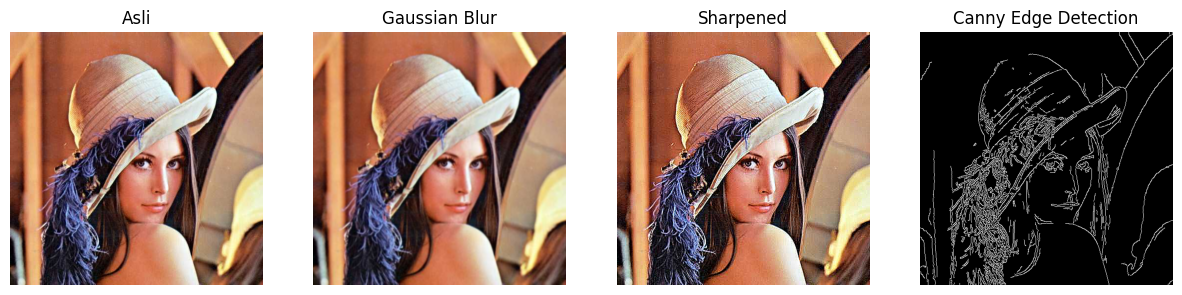

In [33]:
def show_side_by_side(images, titles, figsize=(15,5)):
  plt.figure(figsize=figsize)
  for i, (img, title) in enumerate(zip(images, titles)):
    if len(img.shape) == 2:
      plt.subplot(1, len(images), i+1)
      plt.imshow(img, cmap="gray")
    else:
      plt.subplot(1, len(images), i+1)
      plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
  plt.show()
img = cv.imread(DIR + '/lena.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img, (7,7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)
show_side_by_side([img, blur, sharpened, edges],
                  ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"])

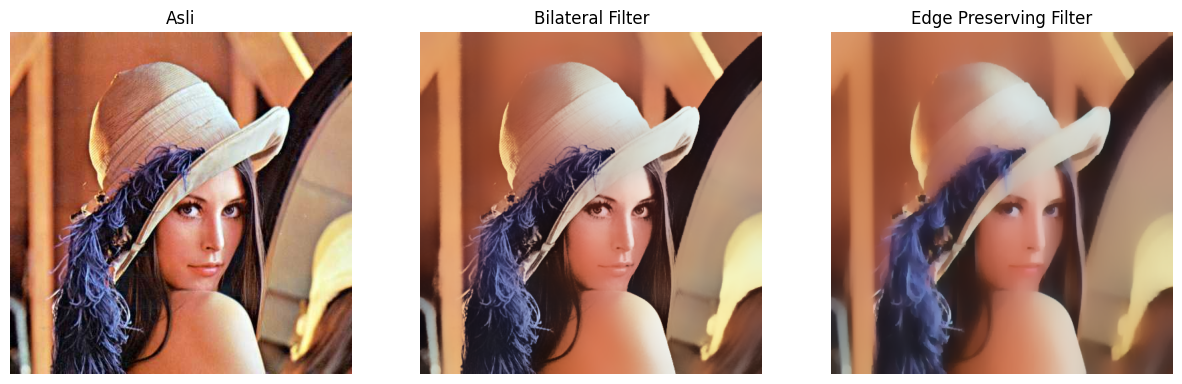

In [34]:
bilateral = cv.bilateralFilter(img, 50, 100, 100)
edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img, bilateral, edge_preserve], ["Asli", "Bilateral Filter", "Edge Preserving Filter"])


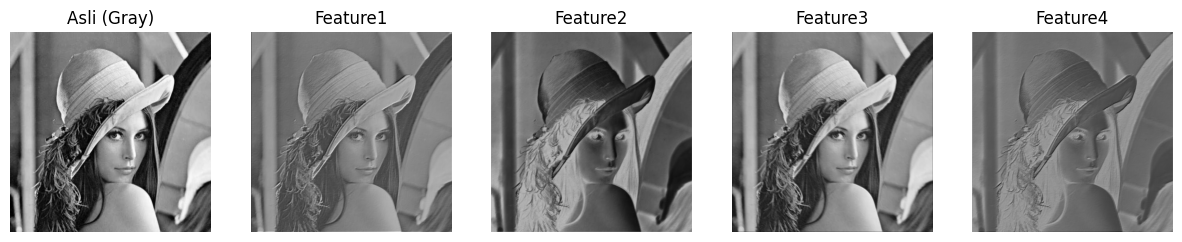

In [39]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv1(x)

model = SimpleCNN()

img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0
with torch.no_grad():
    features = model(img_tensor)


feature_maps = [features[0,i].numpy() for i in range(features.shape[1])]
show_side_by_side([img_gray]+ feature_maps, ["Asli (Gray)"]+ [f"Feature{i+1}" for i in range(len(feature_maps))])

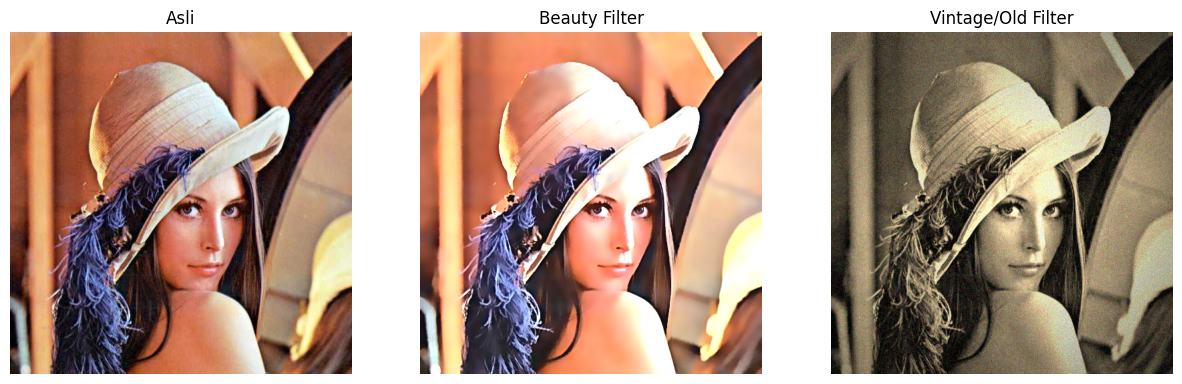

In [47]:
#1. Beauty Filter
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

gaussian = cv.GaussianBlur(smooth, (0,0), 3)
sharpened - cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)

alpha = 1.2
beta = 15
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)

#2. Old?vintage
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])
sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols*0.6)
kernel_y = cv.getGaussianKernel(rows, rows*0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()
vignette = np.copy(sepia)
for i in range(3):
    vignette[:,:,i] = vignette[:,:,i] * mask

noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)
show_side_by_side(
    [img, beauty, old_img],
    ["Asli", "Beauty Filter", "Vintage/Old Filter"]
)